In [2]:
import sys
sys.path.append("..")

import pandas as pd
from storage.parquet_store import ParquetStore
from aggregator.volume_aggregator import VolumeAggregator

store = ParquetStore(base_dir="../storage/data")
aggregator = VolumeAggregator(store)

result = aggregator.absolute_mean()
result = result[result["time"].between("090000", "153000")]
print(result)
print(f"총 {len(result)}개 시간대")

       time        volume
0    090000  24362.142318
1    090100  10321.546487
2    090200   9400.105594
3    090300   8338.747460
4    090400   7750.799387
..      ...           ...
386  152600    777.532995
387  152700   1031.532995
388  152800   1949.944162
389  152900   1686.451777
390  153000  49748.332296

[391 rows x 2 columns]
총 391개 시간대


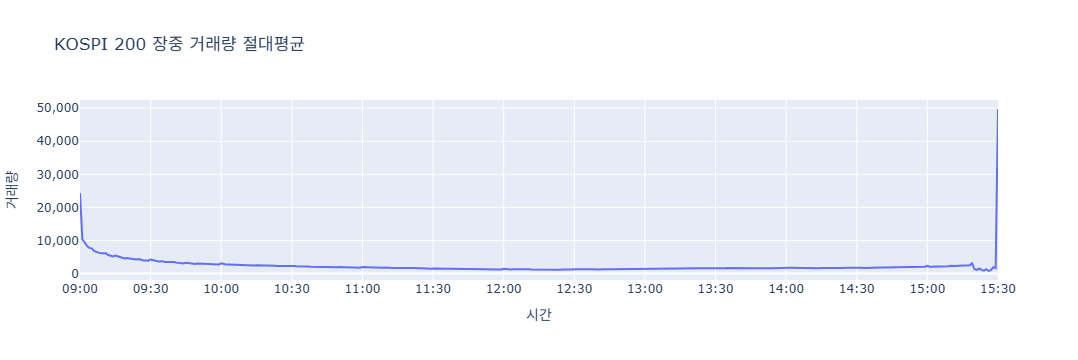

In [7]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=result["time"],
    y=result["volume"],
    mode="lines",
    name="거래량 절대평균"
))

tick_times = [f"{h:02d}{m:02d}00" for h in range(9, 16) for m in range(0, 60, 30) if not (h == 15 and m > 30)]

fig.update_layout(
    title="KOSPI 200 장중 거래량 절대평균",
    xaxis_title="시간",
    yaxis_title="거래량",
    yaxis=dict(
        tickformat=",d"
    ),
    xaxis=dict(
        tickvals=tick_times,
        ticktext=[f"{t[:2]}:{t[2:4]}" for t in tick_times]
    )
)

fig.show()

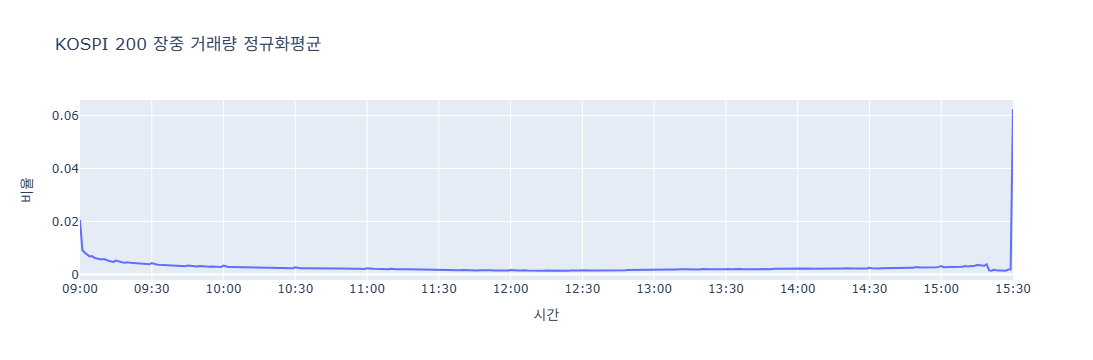

In [5]:
result_norm = aggregator.normalized_mean()
result_norm = result_norm[result_norm["time"].between("090000", "153000")]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=result_norm["time"],
    y=result_norm["norm_volume"],
    mode="lines",
    name="거래량 정규화평균"
))

tick_times = [f"{h:02d}{m:02d}00" for h in range(9, 16) for m in range(0, 60, 30) if not (h == 15 and m > 30)]

fig.update_layout(
    title="KOSPI 200 장중 거래량 정규화평균",
    xaxis_title="시간",
    yaxis_title="비율",
     yaxis=dict(
        tickformat=",d"  # 1000단위 콤마 표시
    )
)
fig.show()

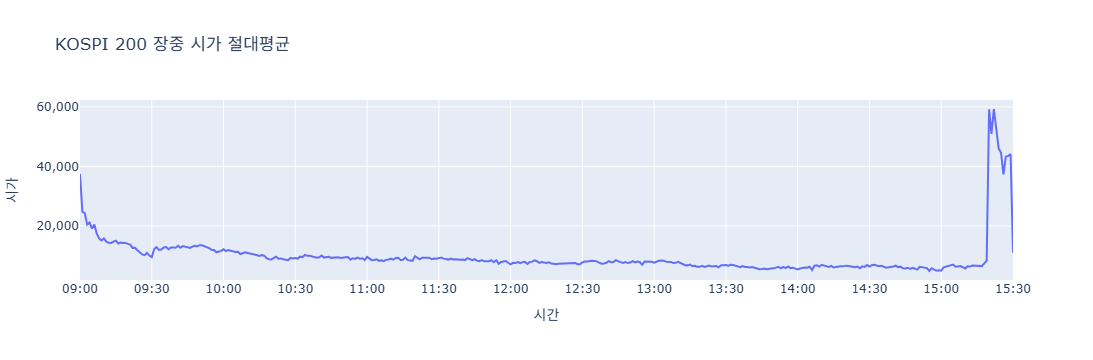

In [9]:
from aggregator.open_aggregator import OpenAggregator

open_aggregator = OpenAggregator(store)
result_open = open_aggregator.absolute_mean()
result_open = result_open[result_open["time"].between("090000", "153000")]

fig2 = go.Figure()
fig2.add_trace(go.Scatter(
    x=result_open["time"],
    y=result_open["open"],
    mode="lines",
    name="시가 절대평균"
))

fig2.update_layout(
    title="KOSPI 200 장중 시가 절대평균",
    xaxis_title="시간",
    yaxis_title="시가",
    yaxis=dict(tickformat=",d"),
    xaxis=dict(
        tickvals=tick_times,
        ticktext=[f"{t[:2]}:{t[2:4]}" for t in tick_times]
    )
)

fig2.show()

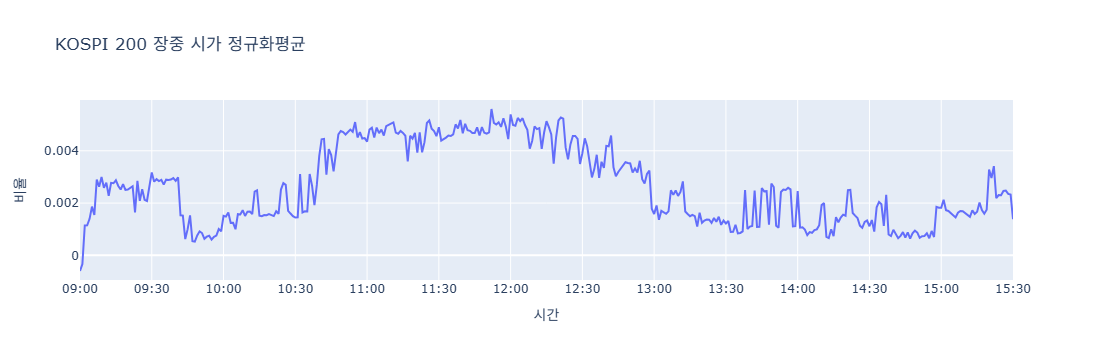

In [10]:
from aggregator.open_aggregator import OpenAggregator

open_aggregator = OpenAggregator(store)
result_open_norm = open_aggregator.normalized_mean()
result_open_norm = result_open_norm[result_open_norm["time"].between("090000", "153000")]

fig3 = go.Figure()
fig3.add_trace(go.Scatter(
    x=result_open_norm["time"],
    y=result_open_norm["norm_open"],
    mode="lines",
    name="시가 정규화평균"
))

fig3.update_layout(
    title="KOSPI 200 장중 시가 정규화평균",
    xaxis_title="시간",
    yaxis_title="비율",
    xaxis=dict(
        tickvals=tick_times,
        ticktext=[f"{t[:2]}:{t[2:4]}" for t in tick_times]
    )
)

fig3.show()

In [11]:
from aggregator.volume_aggregator import VolumeAggregator
result = VolumeAggregator(store).normalized_mean()
print(result.head())

     time  norm_volume
0  090000     0.020529
1  090100     0.009227
2  090200     0.008195
3  090300     0.007423
4  090400     0.006820


In [12]:
df = store.load("005930")
df["open"] = df["open"].astype(float).abs()
df["close"] = df["close"].astype(float).abs()
df["time_label"] = df["time"].apply(lambda t: f"{t[:2]}:{t[2:4]}")
df["val"] = (df["close"] - df["open"]) / df["open"] * 100
result = df.groupby("time_label")["val"].mean()
print(result.head(20))

time_label
09:00    0.006336
09:01    0.002580
09:02    0.022294
09:03   -0.006778
09:04    0.004142
09:05   -0.018377
09:06   -0.022619
09:07    0.004347
09:08    0.009929
09:09    0.009412
09:10   -0.005793
09:11   -0.007007
09:12    0.001855
09:13    0.015579
09:14    0.008372
09:15   -0.014977
09:16    0.024081
09:17   -0.007935
09:18    0.005414
09:19   -0.013606
Name: val, dtype: float64


In [13]:
import pandas as pd
from storage.parquet_store import ParquetStore

store = ParquetStore(base_dir="../storage/data")
tickers = store.load_tickers()

all_df = []
for ticker in tickers:
    df = store.load(ticker)
    df["ticker"] = ticker
    df["open"] = df["open"].astype(float).abs()
    df["close"] = df["close"].astype(float).abs()
    df["time_label"] = df["time"].apply(lambda t: f"{t[:2]}:{t[2:4]}")
    all_df.append(df)

combined = pd.concat(all_df)
combined["val"] = (combined["close"] - combined["open"]) / combined["open"] * 100
result = combined.groupby("time_label")["val"].mean()
print(result.head(20))
print(f"\n최대: {result.max():.6f}")
print(f"\n최소: {result.min():.6f}")
print(f"\n평균: {result.mean():.6f}")

time_label
09:00   -0.053702
09:01   -0.000697
09:02   -0.014769
09:03    0.007065
09:04   -0.009127
09:05   -0.018117
09:06   -0.029133
09:07   -0.009182
09:08   -0.003688
09:09    0.009206
09:10   -0.002266
09:11   -0.000227
09:12    0.005086
09:13    0.007897
09:14   -0.005874
09:15   -0.001899
09:16    0.012131
09:17   -0.006553
09:18    0.008409
09:19    0.001955
Name: val, dtype: float64

최대: 0.052245

최소: -0.053702

평균: 0.002294


In [17]:
import os
print(os.getcwd())  

C:\Users\dbgml\git\quanta\visualizer


In [19]:
import pandas as pd
df = pd.read_parquet("../storage/data/005930.parquet")
print(df[df["time"] >= "151900"].head(10))

          date    time    open    high     low   close   volume
379   20250401  151900  +58900  +58900  +58800  +58800    34032
380   20250401  153000  +58800  +58800  +58800  +58800   684005
381   20250401  153500  +58800  +58800  +58800  +58800     5607
761   20250402  151900  +58900  +59000   58800   58800    72884
762   20250402  153000   58800   58800   58800   58800   963311
763   20250402  153500   58800   58800   58800   58800     5216
1143  20250403  151900  -57200  -57200  -57100  -57200    66618
1144  20250403  153000  -57600  -57600  -57600  -57600  1219313
1145  20250403  153500  -57600  -57600  -57600  -57600     3175
1525  20250404  151900  -56000  -56100  -56000  -56100    66932


In [22]:
import os
path = "../storage/data"
size = sum(os.path.getsize(f"{path}/{f}") for f in os.listdir(path) if f.endswith(".parquet"))
print(f"{size / 1024 / 1024:.1f} MB")

213.5 MB


In [25]:
import pandas as pd
import os

data_path = "../storage/data"
tickers = pd.read_parquet(f"{data_path}/tickers.parquet")["ticker"].tolist()

all_df = []
for ticker in tickers:
    df = pd.read_parquet(f"{data_path}/{ticker}.parquet")
    df["ticker"] = ticker
    all_df.append(df)

combined = pd.concat(all_df)
combined.to_parquet(f"{data_path}/combined.parquet", index=False)
print(f"완료: {len(combined)}행, {os.path.getsize(f'{data_path}/combined.parquet') / 1024 / 1024:.1f} MB")

완료: 19179172행, 135.3 MB


In [26]:
import pandas as pd
import os

data_path = "../storage/data"
tickers = pd.read_parquet(f"{data_path}/tickers.parquet")["ticker"].tolist()

all_df = []
for ticker in tickers:
    df = pd.read_parquet(f"{data_path}/{ticker}.parquet")
    df["ticker"] = ticker
    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = df[col].astype(float).abs()
    df["date"] = df["date"].astype("category")
    df["time"] = df["time"].astype("category")
    df["ticker"] = df["ticker"].astype("category")
    all_df.append(df)

combined = pd.concat(all_df)
combined.to_parquet(f"{data_path}/combined.parquet", index=False)
size = os.path.getsize(f"{data_path}/combined.parquet") / 1024 / 1024
print(f"완료: {len(combined)}행, {size:.1f} MB")

완료: 19179172행, 125.7 MB


In [28]:
import pandas as pd

df = pd.read_parquet(r"C:\Users\dbgml\git\quanta\storage\data\005930.parquet")
today = df["date"].max()
today_df = df[df["date"] == today]
print(f"날짜: {today}")
print(f"분봉 수: {len(today_df)}")
print(today_df["time"].sort_values().tolist())


날짜: 20260420
분봉 수: 381
['090000', '090100', '090200', '090300', '090400', '090500', '090600', '090700', '090800', '090900', '091000', '091100', '091200', '091300', '091400', '091500', '091600', '091700', '091800', '091900', '092000', '092100', '092200', '092300', '092400', '092500', '092600', '092700', '092800', '092900', '093000', '093100', '093200', '093300', '093400', '093500', '093600', '093700', '093800', '093900', '094000', '094100', '094200', '094300', '094400', '094500', '094600', '094700', '094800', '094900', '095000', '095100', '095200', '095300', '095400', '095500', '095600', '095700', '095800', '095900', '100000', '100100', '100200', '100300', '100400', '100500', '100600', '100700', '100800', '100900', '101000', '101100', '101200', '101300', '101400', '101500', '101600', '101700', '101800', '101900', '102000', '102100', '102200', '102300', '102400', '102500', '102600', '102700', '102800', '102900', '103000', '103100', '103200', '103300', '103400', '103500', '103600', '10370